In [26]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [27]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The images are 32x32 pixels and have three color channels (red, green blue).

In [28]:
#Data loading
# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


### Lets see some example images from dataset, n=15 images for each class from training dataset we defined above.

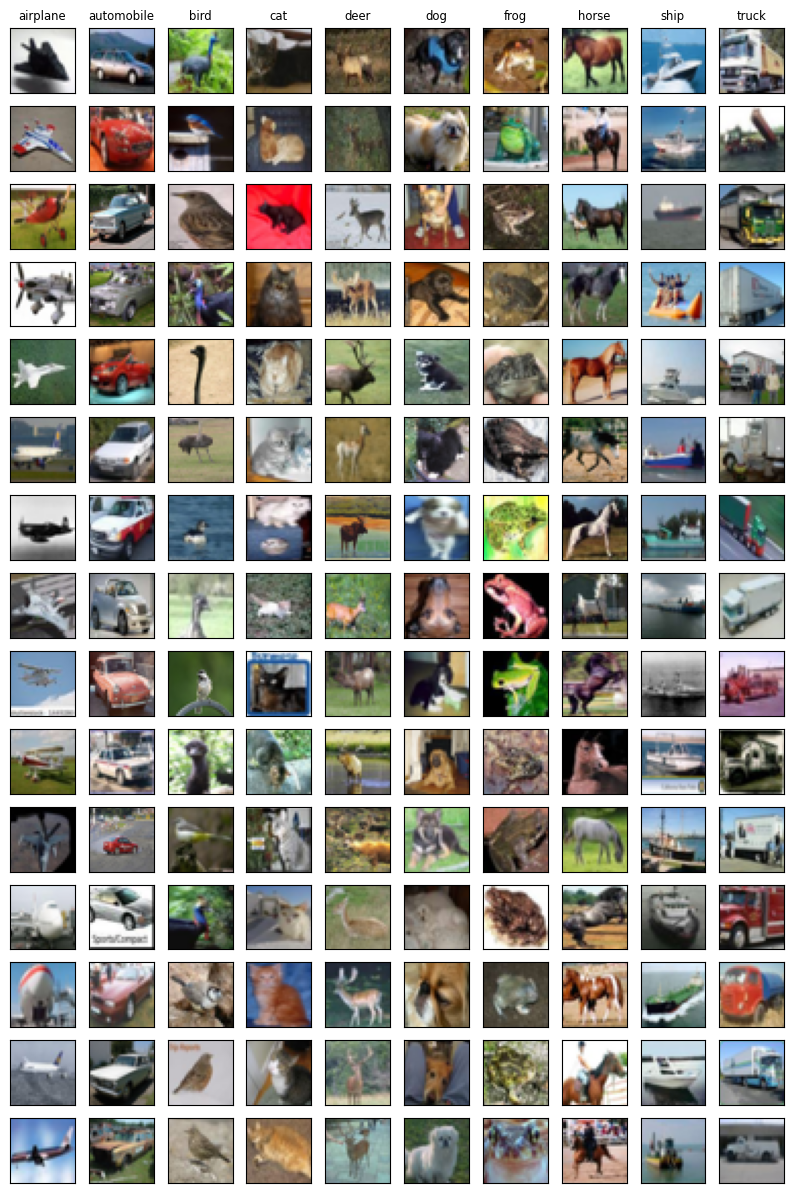

In [29]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train, n=15)
plt.show()

### Preprocessing and Data Splitting into Train, Test and Validation sets

In [30]:
import numpy as np

# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Normalize the data and split test data for validation
x_train_norm = x_train.astype('float32') / 255.0

# Split x_test into test and validation sets, then normalize
x_test_split = x_test[:8000]
x_valid_split = x_test[8000:]

x_test_norm = x_test_split.astype('float32') / 255.0
x_valid_norm = x_valid_split.astype('float32') / 255.0

print(f"x_train_norm shape: {x_train_norm.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"x_test_norm shape: {x_test_norm.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")
print(f"x_valid_norm shape: {x_valid_norm.shape}")
print(f"y_valid_onehot shape: {y_valid_onehot.shape}")

x_train_norm shape: (50000, 32, 32, 3)
y_train_onehot shape: (50000, 10)
x_test_norm shape: (8000, 32, 32, 3)
y_test_onehot shape: (8000, 10)
x_valid_norm shape: (2000, 32, 32, 3)
y_valid_onehot shape: (2000, 10)


### Model 1: Image Classification with Fully Connected Neural Network (FCNN)

First we have input 2D image of 32x32x8 size flattened into input layer of = 3072 nodes. Then we have two hidden layers with 256 nodes each and a dropout layer in between to prevent overfitting. the final hidden layer is then connected to output layer via softmax activation function for categorisation probabilities.

In [31]:

# Define model

model = tf.keras.models.Sequential(
    [
        layers.Flatten(input_shape=(32, 32, 3)),  # (32,32,3) --> (3072)
        # this time the flatten operation is directly integrated into the network

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25), # Added dropout layer
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax') # Output layer with 10 nodes and softmax activation
    ],
    name="nn",
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,050 (3.26 MB)

 Trainable params: 855,050 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

None


The total number of trainable parameters are 855,050 for this fully connected neural network.

### Model 1: Training the FCNN for 40 epochs:

In [32]:

import time

# Training

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=64,
    epochs=40, # train at least for 40 epochs
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

end_time = time.time()
training_time = end_time - start_time
print(f"FCNN training took: {training_time:.2f} seconds")

Epoch 1/40
782/782 - 8s - 10ms/step - accuracy: 0.2733 - loss: 1.9876 - val_accuracy: 0.3550 - val_loss: 1.8106
Epoch 2/40
782/782 - 7s - 9ms/step - accuracy: 0.3253 - loss: 1.8587 - val_accuracy: 0.3805 - val_loss: 1.7463
Epoch 3/40
782/782 - 6s - 8ms/step - accuracy: 0.3468 - loss: 1.7989 - val_accuracy: 0.3910 - val_loss: 1.7207
Epoch 4/40
782/782 - 11s - 14ms/step - accuracy: 0.3547 - loss: 1.7804 - val_accuracy: 0.3870 - val_loss: 1.7106
Epoch 5/40
782/782 - 10s - 13ms/step - accuracy: 0.3614 - loss: 1.7564 - val_accuracy: 0.3965 - val_loss: 1.7076
Epoch 6/40
782/782 - 7s - 9ms/step - accuracy: 0.3740 - loss: 1.7307 - val_accuracy: 0.3830 - val_loss: 1.7166
Epoch 7/40
782/782 - 7s - 9ms/step - accuracy: 0.3811 - loss: 1.7138 - val_accuracy: 0.4165 - val_loss: 1.6537
Epoch 8/40
782/782 - 9s - 12ms/step - accuracy: 0.3850 - loss: 1.7011 - val_accuracy: 0.4080 - val_loss: 1.6507
Epoch 9/40
782/782 - 7s - 9ms/step - accuracy: 0.3847 - loss: 1.7037 - val_accuracy: 0.4435 - val_loss: 1.

### Visualisation of Network Performance

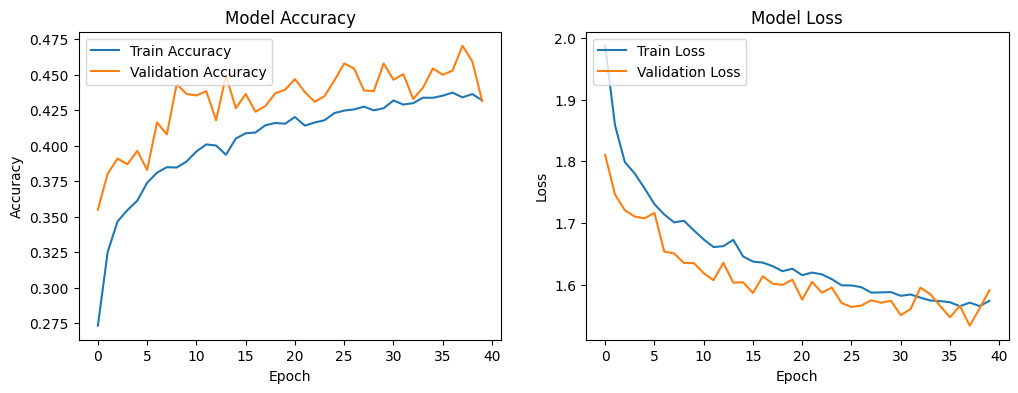

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


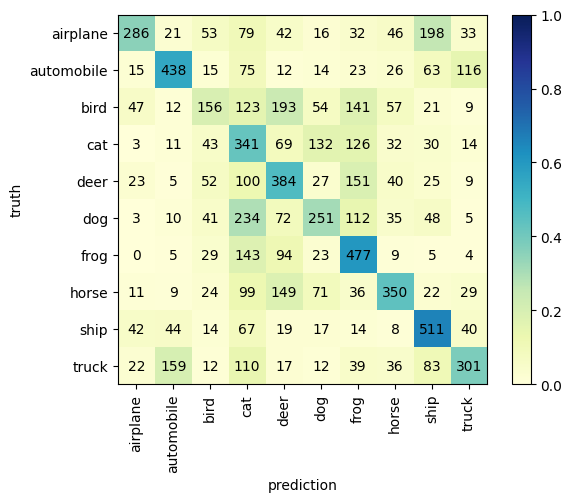

In [33]:

# Plots

# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['loss'], label='Train Loss')
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)
plt.show()

### FCNN Performance Metrics

In [34]:
print(f"Final Training Accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_accuracy'][-1]:.4f}")

loss, accuracy = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"Final Test Accuracy: {accuracy:.4f}")

print(f"Training took time: {training_time:.4f}s")

Final Training Accuracy: 0.4320
Final Validation Accuracy: 0.4315
Final Test Accuracy: 0.4369
Training took time: 302.4978s


Above figures shows how accuracy and model loss varies with increasing epochs for validation and training dataset through the fully connected neural network. The train loss and validation loss are generally decreasing, showing the model neither overfitting nor underfitting. The model accuracy is also increasing with increasing epochs. The rate of change of accuracy is higher in the beginning, but the curve gets essentially linear after 4 epochs. Furthur increase in epochs isnt drastically improving the accuracy of the model. After 20 epochs, the validation accuracy  is only 43.15% and test accuracy is 43.69%.

From Confusion Matrix, we can get more insights about the network´s performance. The Diagonal shows when model´s prediction´s were correct. Off-diagonal terms shows false predictions. The maximum false predictions were for dogs 234 times misidentified as cat. Then bird 193 times misidentified as deer. Another interesting observation is that most misidentification spreads were found for cats and dogs and then birds and horses,  are misidentified with multiple different categories. That is, less confident about these decisions. Whereas the model was less wrong for airplane, automobile, ship and trucks, which are comparatively less complex structures and doesnt have complex and fine features to learn. Hence, fully connected neural networks couldnt capture and learn fine features that could enable them distinguish cats, dogs and horses from each other.

It is because when an image is flattened into a 1D vector (as done in the FCNN here), the spatial relationships between pixels are lost. A FCNN struggles to understand local patterns and their positions within the image.While idealising input structure for the deep neural networks, some information about consecutive pixel correlations is lost, which could have served as important pattern. Hence, neural networks arent optimised for datasets where each consecutive neuron or pixel is correlated.

 Fully connected neural networks also lack inherent translation invariance. If a feature moves to a different position, the flattened input changes dramatically, and the network might treat it as an entirely new featur


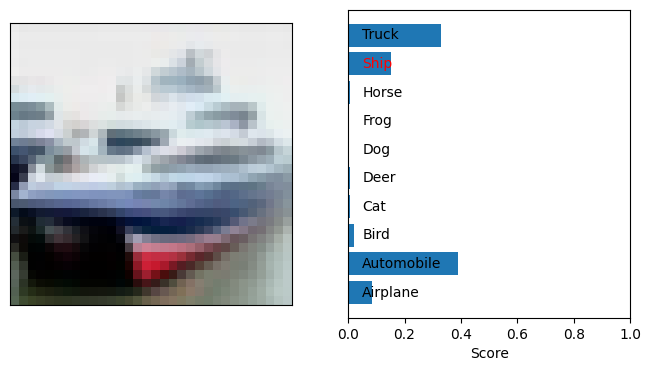

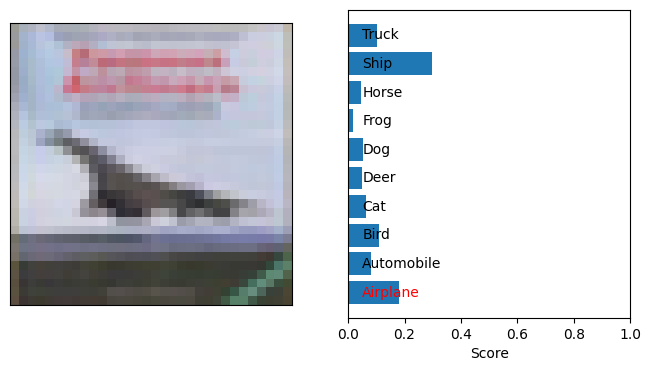

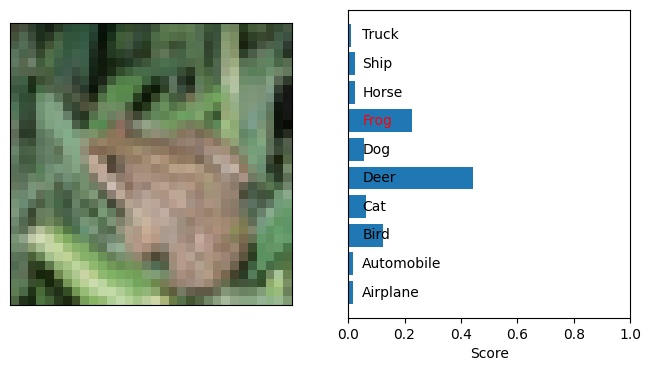

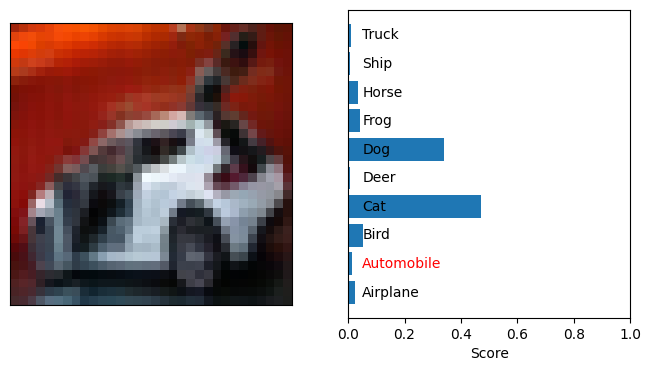

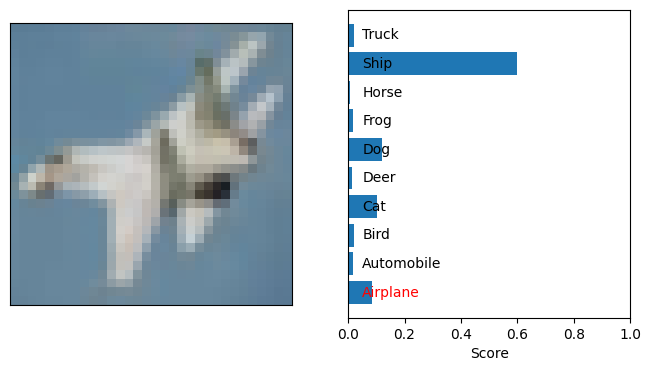

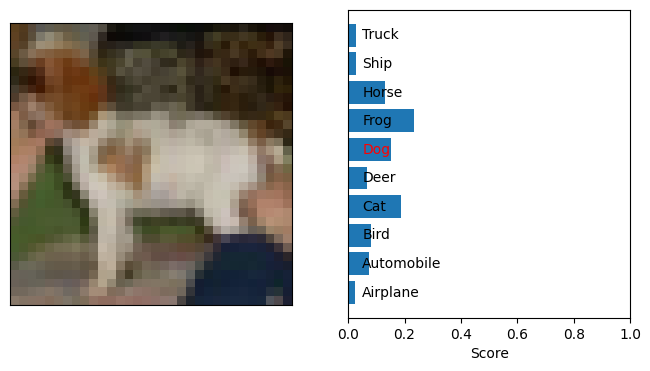

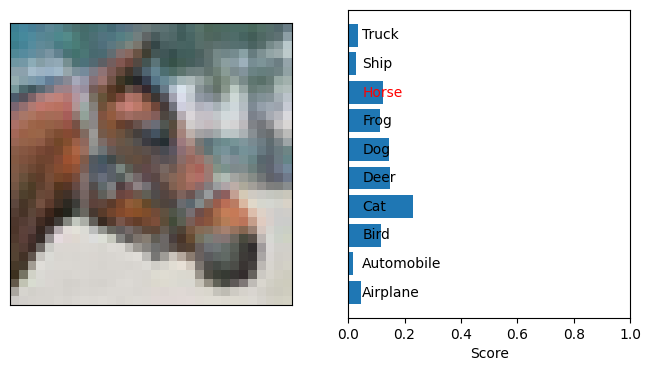

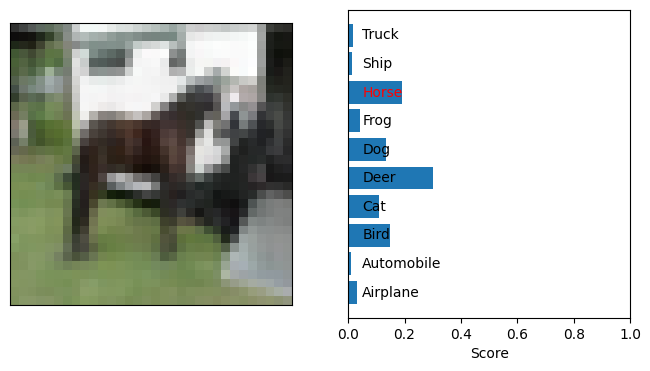

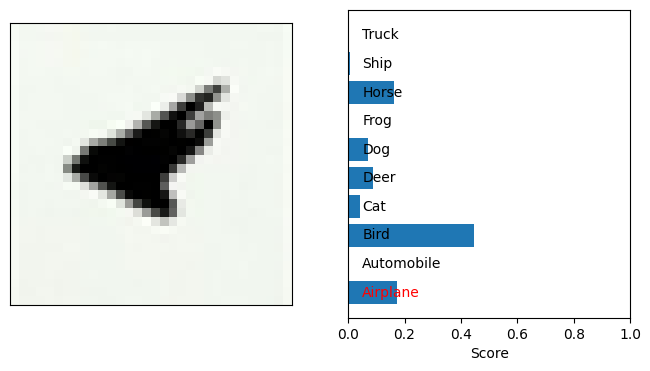

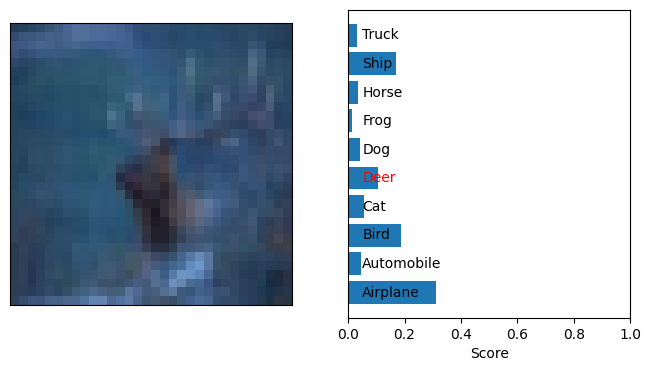

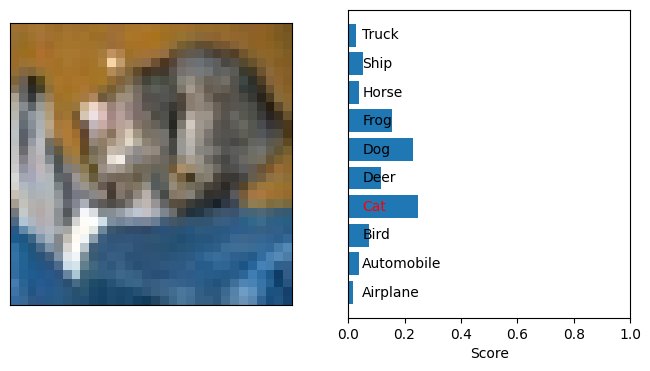

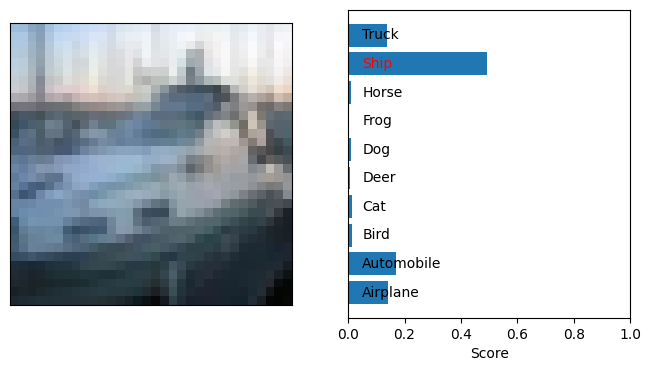

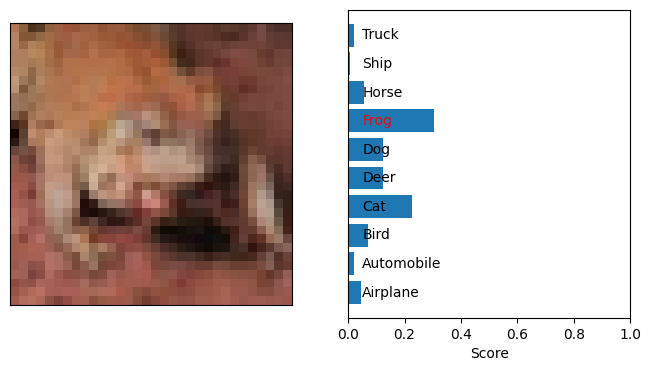

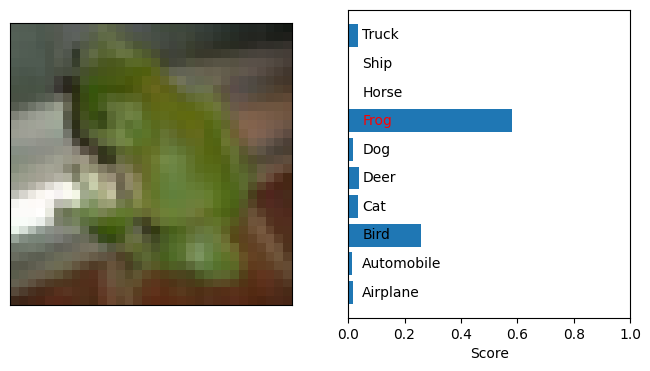

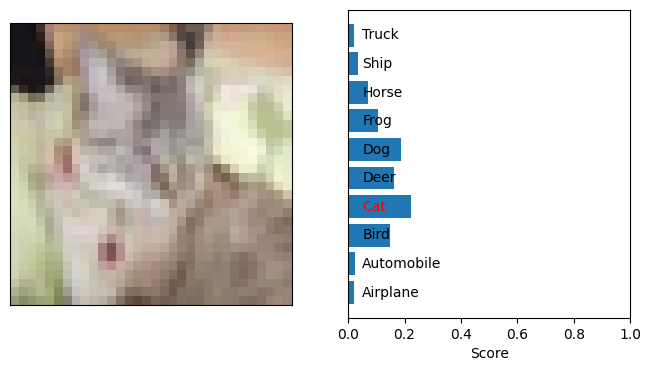

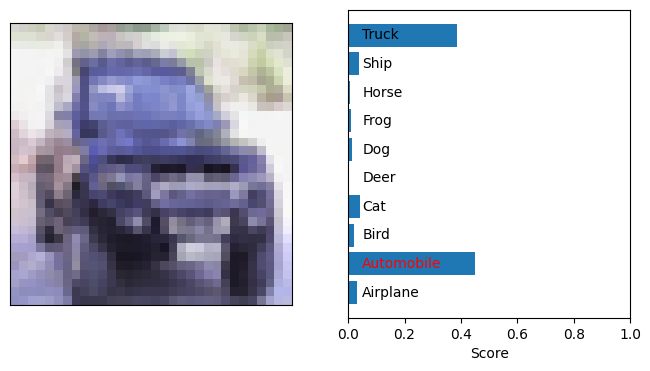

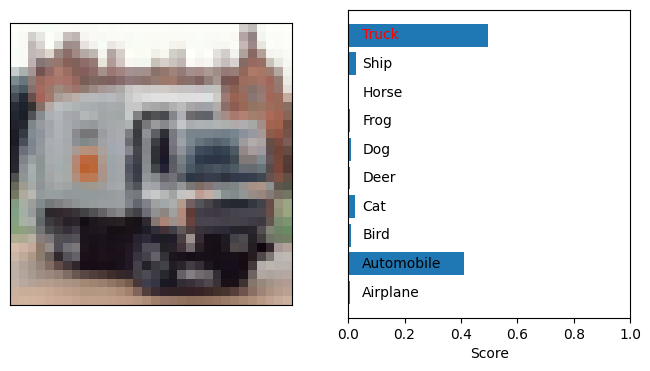

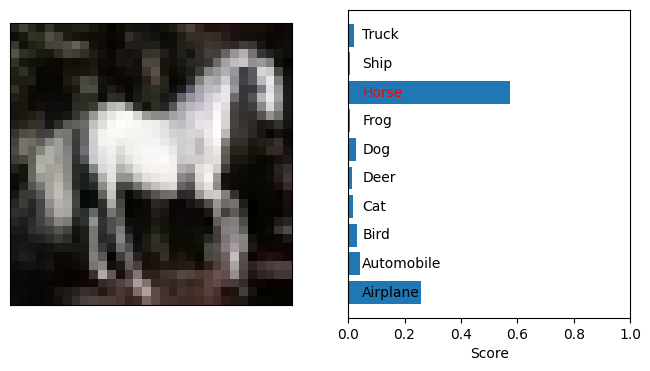

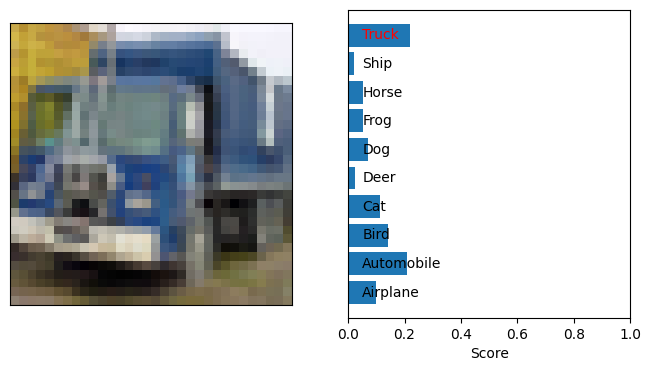

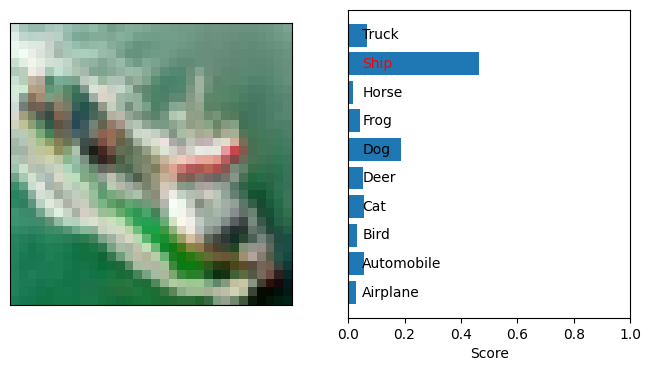

In [35]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 10 false classifications
for i in i0[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

# plot first 10 correctly classified images
for i in i1[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

We can see that the model is more confident for airplanes, trucks etc. However, less confident/higher loss for living creatures with intricate features.


### Model 2: Image Classification with a CNN.


In [15]:
# Hint: this code snipped shows how to define convolution and maxpooling layers. For more information see
# https://keras.io/api/layers/convolution_layers/convolution2d/
# https://keras.io/api/layers/pooling_layers/max_pooling2d/
model = tf.keras.models.Sequential(
    [
        layers.Conv2D(16, kernel_size=(3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"), # additional convolutional layer
        layers.MaxPooling2D((2,2)), # additional max pooling layer
        layers.Flatten(),
        layers.Dropout(0.25), # add dropout
        layers.Dense(10, activation='softmax') # output layer
    ],
    name="cnn",
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

None


The total number of trainable parameters for this Convolutional Neural Network is 25,578. Here's how layer by layer:

1.  **`conv2d` (First Convolutional Layer):**
    *   Input channels: 3 (RGB image)
    *   Kernel size: 3x3
    *   Output filters: 16
    *   Parameters = `(kernel_height * kernel_width * input_channels + 1) * output_filters`
    *   Parameters = `(3 * 3 * 3 + 1) * 16 = (27 + 1) * 16 = 28 * 16 = 448`

2.  **`max_pooling2d` (First Max Pooling Layer):**
    *   No trainable parameters.
    *   Parameters = `0`

3.  **`conv2d_1` (Second Convolutional Layer):**
    *   Input channels: 16 (from previous layer)
    *   Kernel size: 3x3
    *   Output filters: 32
    *   Parameters = `(kernel_height * kernel_width * input_channels + 1) * output_filters`
    *   Parameters = `(3 * 3 * 16 + 1) * 32 = (144 + 1) * 32 = 145 * 32 = 4640`

4.  **`max_pooling2d_1` (Second Max Pooling Layer):**
    *   No trainable parameters.
    *   Parameters = `0`

5.  **`flatten` (Flatten Layer):**
    *   No trainable parameters.
    *   Parameters = `0`
    *   (Output from `max_pooling2d_1` is `8x8x32`, so flattened size is `8 * 8 * 32 = 2048`)

6.  **`dropout` (Dropout Layer):**
    *   No trainable parameters.
    *   Parameters = `0`

7.  **`dense` (Output Dense Layer):**
    *   Input units: 2048 (from flattened layer)
    *   Output units: 10 (for 10 classes)
    *   Parameters = `(input_units + 1) * output_units`
    *   Parameters = `(2048 + 1) * 10 = 2049 * 10 = 20490`

**Total Trainable Parameters =** `448 + 0 + 4640 + 0 + 0 + 0 + 20490 = 25578`.

### Training the CNN for 40 epochs

In [16]:
import time


# Training

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=64,
    epochs=40,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

end_time = time.time()
training_time = end_time - start_time
print(f"CNN training took: {training_time:.2f} seconds")

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4364 - loss: 1.5808 - val_accuracy: 0.4905 - val_loss: 1.3891
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5497 - loss: 1.2773 - val_accuracy: 0.5620 - val_loss: 1.2338
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5920 - loss: 1.1672 - val_accuracy: 0.5970 - val_loss: 1.1310
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6227 - loss: 1.0888 - val_accuracy: 0.6345 - val_loss: 1.0515
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6402 - loss: 1.0383 - val_accuracy: 0.6335 - val_loss: 1.0366
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.6509 - loss: 1.0063 - val_accuracy: 0.6460 - val_loss: 1.0113
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.6656 - loss: 0.9703 - val_accuracy: 0.6585 - val_loss: 0.9850
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.6710 - loss: 0.9490 - 

### Performance Visualisation

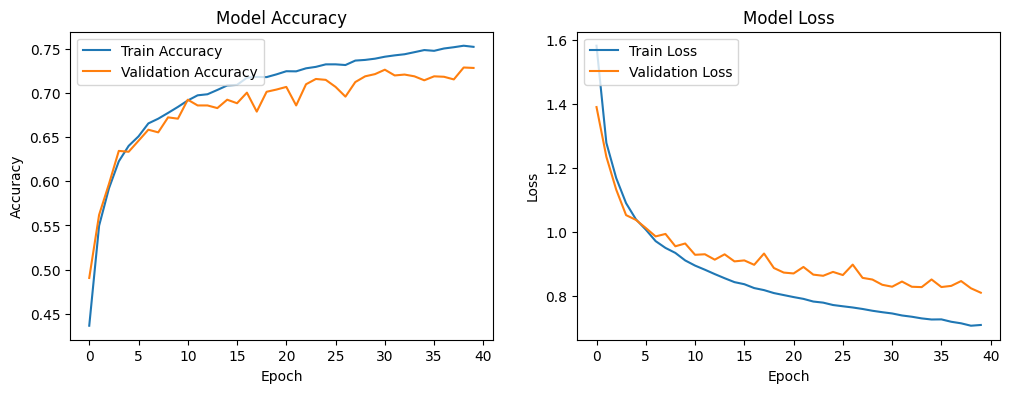

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


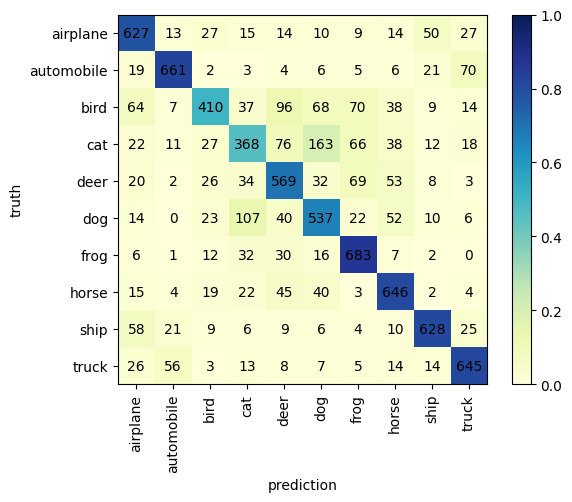

In [17]:

# Plots

# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['loss'], label='Train Loss')
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)
plt.show()

In [18]:
print(f"Final Training Accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_accuracy'][-1]:.4f}")

loss, accuracy = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"Final Test Accuracy: {accuracy:.4f}")

Final Training Accuracy: 0.7524
Final Validation Accuracy: 0.7285
Final Test Accuracy: 0.7218


CNN acheived validation accuracy of nearly 67% after 10 epochs, and 72.85% after 40 epochs. Test accuracy is 72.18% after  40 epochs. One interesting observation is that the model generally performed better on train dataset than validation, as shown by higher accuracy from 10 epochs onwards and decreasing train loss, showing a minor degree of overfitting.

The confusion matrux shows that misidentification numbers are overall reduced. However, maximum misidentification are still clustered around birds, cats, dogs and horses. However, maximum misidentifaction is cat 163 times taken as dog. Whereas in FCNN, it was 132. Similarly, CNN 107 times dogs misidentified with cats. Whereas for FCNN, it was 234. Hence, good progress could be seen especially, for automobile, frog, ship, horses and truck. However, cats and dogs expect more improvement.

CNN has performed exceptionally well as compared to fully connected neural networks, considering CNN only had 25,578 learnable parameters as compared to 855050 parameters needed for FCNN. It shows that merely increasing the number of learnable parameters doesnt suffice to ensure that model learn right features and patterns. CNNs learns the spatial heirerchies of features in the input images via concolutional layers. It preserves the 2D structure of the image and utilises the consecutive pixels correlations. Each filter learns a specific feature, based on spatial arrangements of pixels. Additionally CNNs have translational invariance, hence location of for example, cat´s eye in different spatial position in image isnt taken as new feature.




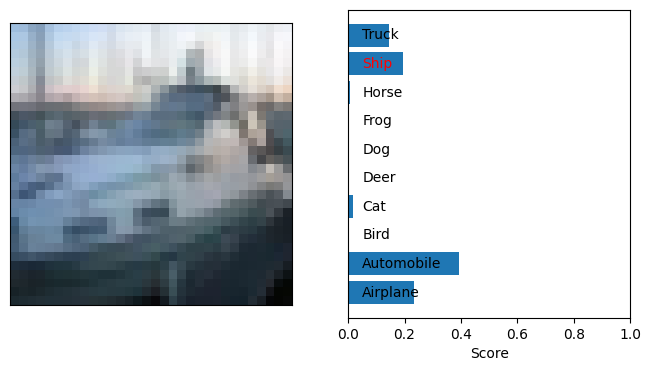

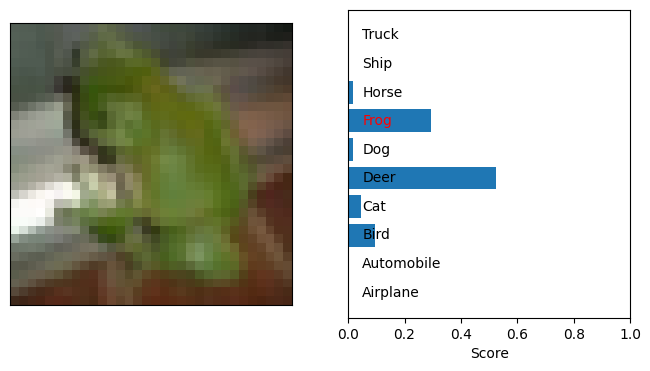

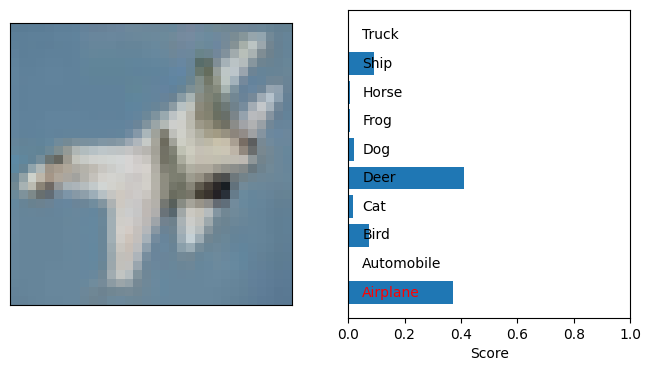

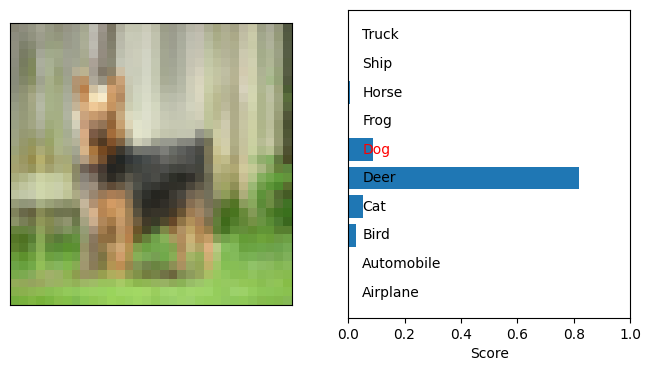

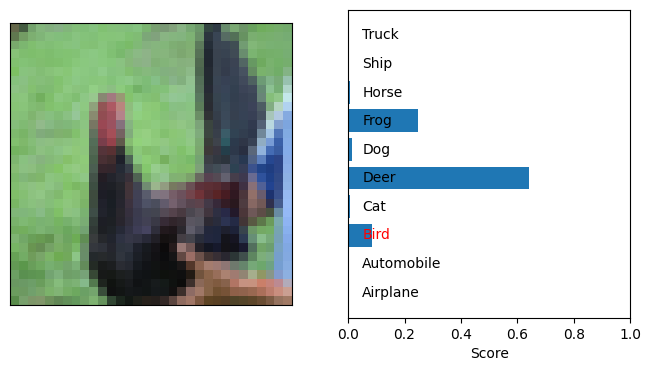

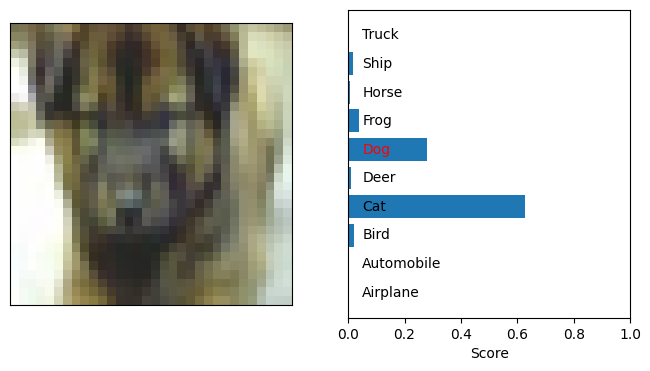

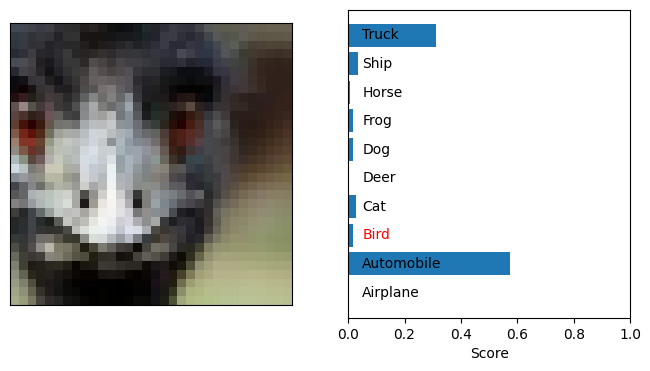

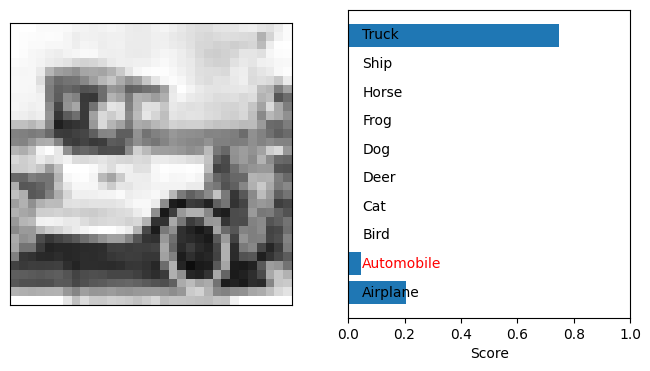

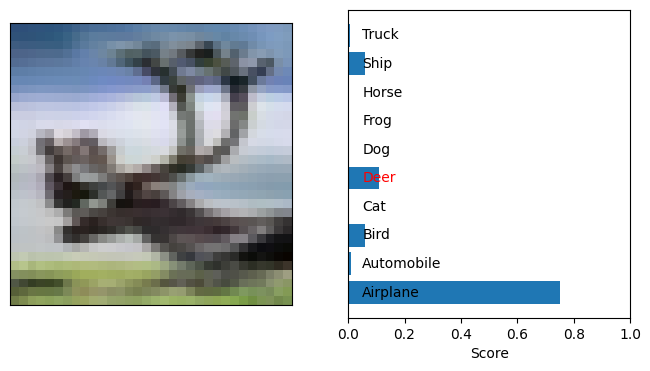

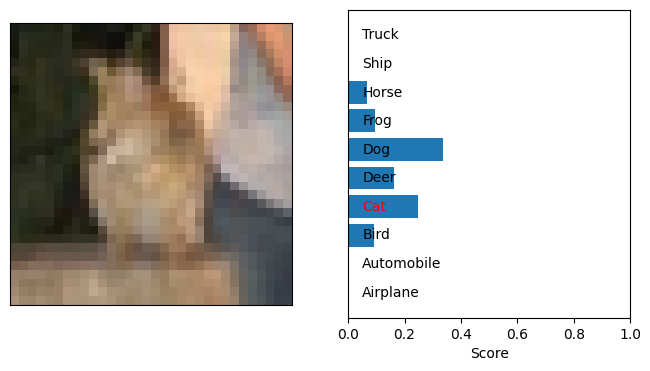

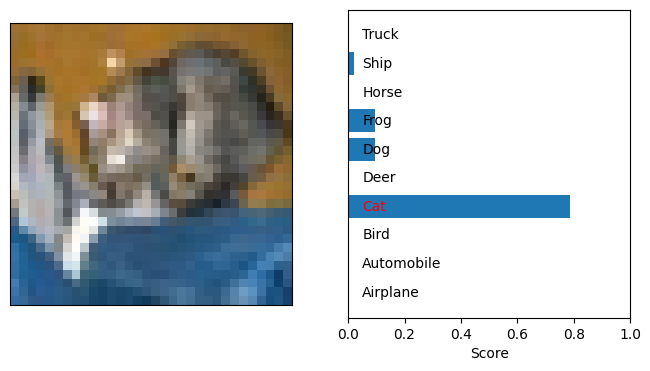

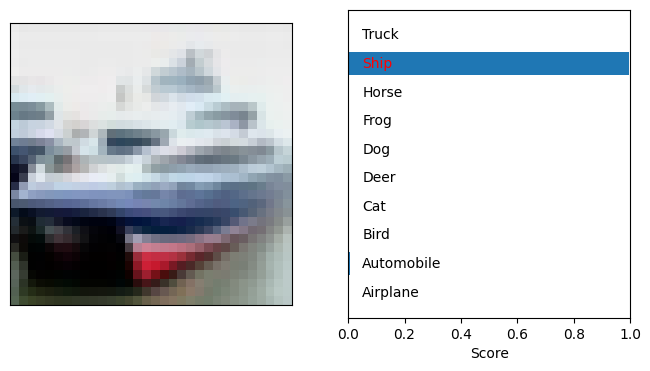

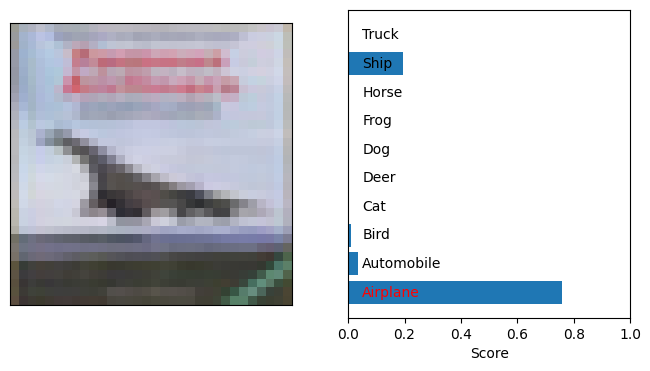

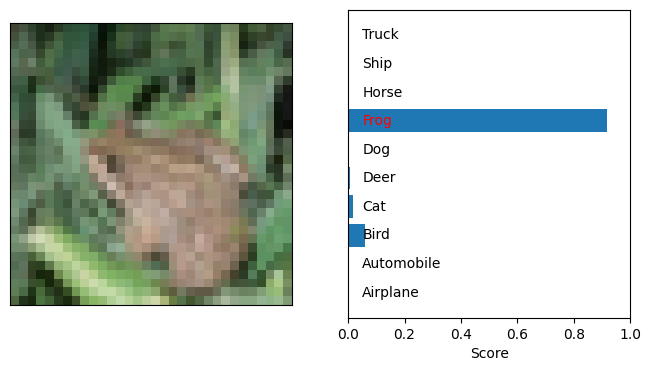

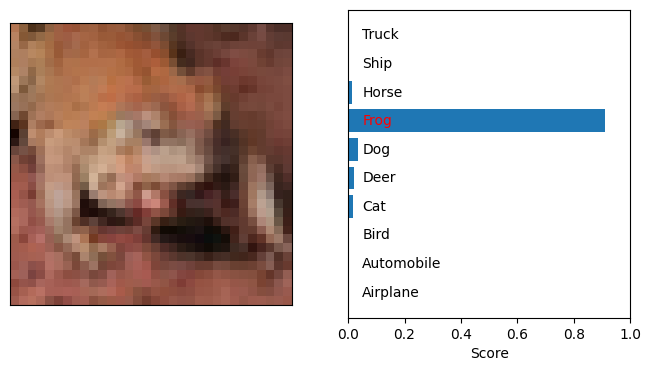

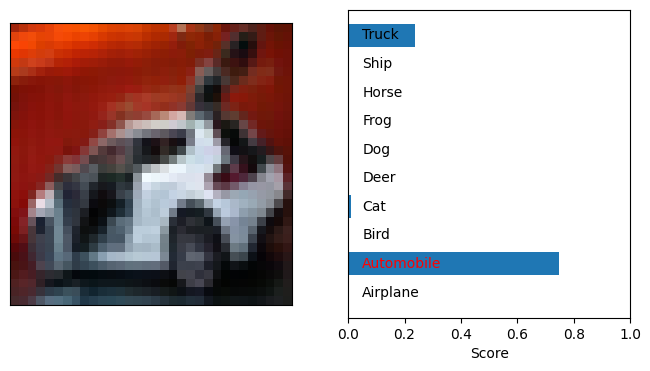

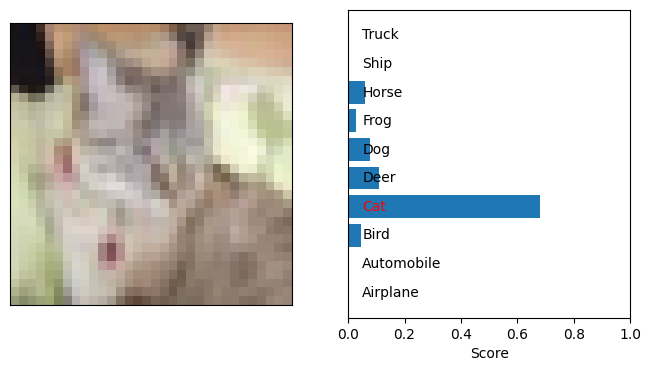

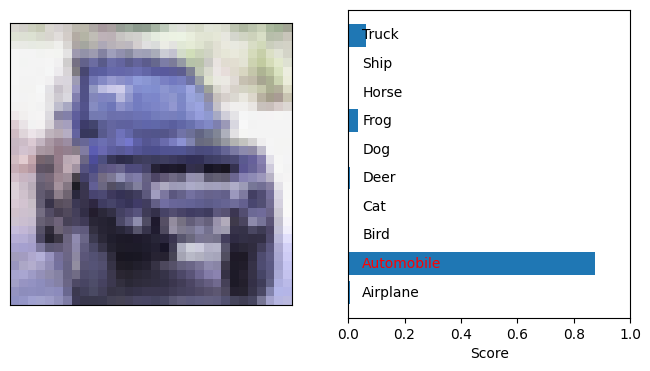

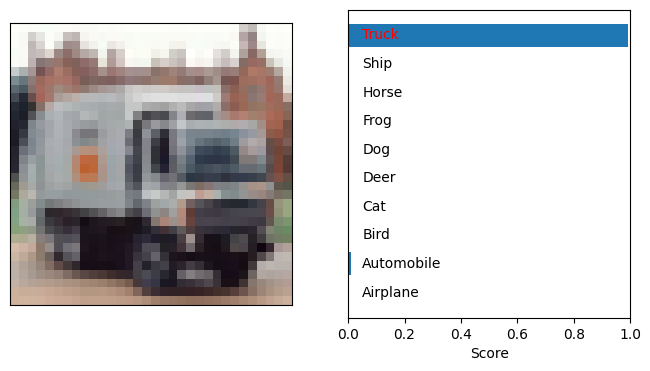

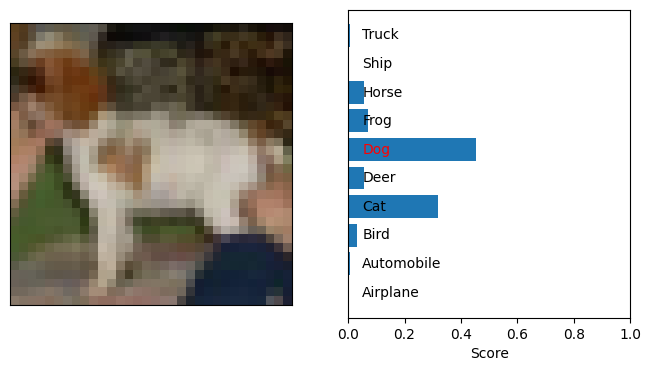

In [19]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 10 false classifications
for i in i0[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

# plot first 10 correctly classified images
for i in i1[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

The images shows, that model often misclassified the images that visually are really close to other categories.

In [38]:
import pandas as pd
import numpy as np

# Data for FCNN (40 epochs) - using user-provided values
fcnn_40_epochs = {
    "Model": "FCNN (40 Epochs)",
    "Training Accuracy": 0.4320,
    "Validation Accuracy": 0.4315,
    "Test Accuracy": 0.4369,
    "Training Time (s)": 302.4978,
    "Parameters": 855050
}

# Data for CNN (40 epochs) - using user-provided values
cnn_40_epochs = {
    "Model": "CNN (40 Epochs)",
    "Training Accuracy": 0.7524,
    "Validation Accuracy": 0.7285,
    "Test Accuracy": 0.7218,
    "Training Time (s)": 1176.58,
    "Parameters": 25578
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([fcnn_40_epochs, cnn_40_epochs])

print("### Model Performance Comparison\n")
print(comparison_df.to_markdown(index=False, numalign="left", stralign="left", floatfmt=".4f"))

print("\nNote: All metrics are based on the latest successful runs of each model.")

### Model Performance Comparison

| Model            | Training Accuracy   | Validation Accuracy   | Test Accuracy   | Training Time (s)   | Parameters   |
|:-----------------|:--------------------|:----------------------|:----------------|:--------------------|:-------------|
| FCNN (40 Epochs) | 0.4320              | 0.4315                | 0.4369          | 302.4978            | 855050       |
| CNN (40 Epochs)  | 0.7524              | 0.7285                | 0.7218          | 1176.5800           | 25578        |

Note: All metrics are based on the latest successful runs of each model.


### Conclusion

For image data, CNNs are designed to capture the local patterns and spatial relationships that are lost when an image is flattened for a traditional fully connected neural networks. This architectural advantage makes them far more effective and efficient for tasks like image classification, as clearly demonstrated by the significantly higher accuracy of the CNN model compared to the FCNN model, despite having fewer parameters.



### How to Improve CNN Classifier for CIFAR dataset

**Data Augmentation:** This is one of the most effective ways to improve generalization and reduce overfitting, especially with limited datasets like CIFAR-10. We can apply various transformations to the training images such as:

Random rotations
Random shifts (horizontal/vertical)
Random flips (horizontal)
Zooming
Brightness changes Keras provides ImageDataGenerator for this purpose.

**Deeper and More Complex Architectures:** Adding more convolutional and pooling layers can help the model learn more complex and abstract features. Addiitonally, gradually increasing the number of filters in convolutional layers could allow the model to learn a wider variety of features.

**More regularization techniques** (beyond dropout) could also help, prevent overfitting. It includes:
Batch Normalization: Add tf.keras.layers.BatchNormalization() layers, typically after convolutional layers and before activation functions. This helps stabilize training, allows for higher learning rates, and can improve performance.
L1/L2 Regularization: Apply L1 or L2 regularization to the kernel weights of  convolutional and dense layers to penalize large weights and prevent overfitting.

**Hyperparameter Tuning:**

Instead of a fixed learning rate, we can use learning rate schedulers (e.g., ReduceLROnPlateau, ExponentialDecay) to dynamically adjust the learning rate during training.
We may experiment with other optimizers like RMSprop, Adagrad, or more advanced ones like AdamW or Ranger, just to get rid of benefit of doubt for other techniques.
Testing different batch sizes to see their impact on training stability and performance could be helpful.
Addiitonally,  Fine-tuning the dropout rates in dropout layers, could also be done.

A grid search or random search could be done to fine tune hyperparameters.